In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_train = pd.read_csv("comment-category-prediction-challenge/train.csv") 
df_test = pd.read_csv("comment-category-prediction-challenge/test.csv") 

df_test["is_train"] = 0
df_train["is_train"] = 1
sample = pd.read_csv("comment-category-prediction-challenge/Sample.csv") 

In [3]:
df_train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2,1
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0,1
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2,1
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2,1
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2,1


### Let's start with feature engi and EDA on both train and test data

In [4]:
df = pd.concat([df_train, df_test], ignore_index=True) #merged it so we can perform essentail eda and fe on both datasets
df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2.0,1
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0.0,1
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2.0,1
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2.0,1
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,2023-09-26 03:14:06.328881+00:00,72,0,0,0,1,0,0,4,NaN,NaN,NaN,False,Working in McDonald's is easy (pain in the pos...,NaN,0
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov...",NaN,0
299997,2023-10-26 15:41:55.972421+00:00,72,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetwor...,NaN,0
299998,2024-02-28 11:25:10.033561+00:00,72,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau no...,NaN,0


In [5]:
numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
len(numerical_objs)

10

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   created_date  300000 non-null  str    
 1   post_id       300000 non-null  int64  
 2   emoticon_1    300000 non-null  int64  
 3   emoticon_2    300000 non-null  int64  
 4   emoticon_3    300000 non-null  int64  
 5   upvote        300000 non-null  int64  
 6   downvote      300000 non-null  int64  
 7   if_1          300000 non-null  int64  
 8   if_2          300000 non-null  int64  
 9   race          79308 non-null   str    
 10  religion      79308 non-null   str    
 11  gender        79308 non-null   str    
 12  disability    300000 non-null  bool   
 13  comment       299999 non-null  str    
 14  label         198000 non-null  float64
 15  is_train      300000 non-null  int64  
dtypes: bool(1), float64(1), int64(9), str(5)
memory usage: 34.6 MB


In [7]:
display(df['race'].unique())
display(df['religion'].unique())
display(df['gender'].unique())
display(df['disability'].unique())
display(df['created_date'].unique())

<StringArray>
[nan, 'none', 'white', 'other', 'asian', 'black', 'latino']
Length: 7, dtype: str

<StringArray>
[        nan, 'christian',    'muslim',      'none',    'jewish',   'atheist',
     'other',     'hindu',  'buddhist']
Length: 9, dtype: str

<StringArray>
[nan, 'none', 'male', 'female', 'transgender', 'other']
Length: 6, dtype: str

array([False,  True])

<StringArray>
['2024-01-18 08:43:57.397508+00:00', '2024-03-24 21:43:11.490017+00:00',
 '2024-04-24 20:32:17.014931+00:00', '2023-05-28 22:00:14.214527+00:00',
 '2023-09-09 23:12:05.689498+00:00', '2024-04-06 20:10:59.141468+00:00',
 '2024-03-04 03:02:55.849172+00:00', '2023-10-14 20:57:30.208573+00:00',
 '2024-02-24 12:13:22.166045+00:00', '2023-08-07 20:35:35.968324+00:00',
 ...
 '2023-11-11 05:04:03.749590+00:00', '2024-04-06 08:41:04.924689+00:00',
 '2024-04-30 19:10:35.930782+00:00', '2024-05-04 07:53:11.994478+00:00',
 '2023-06-16 18:43:17.385957+00:00', '2023-09-26 03:14:06.328881+00:00',
 '2023-08-18 19:30:16.601996+00:00', '2023-10-26 15:41:55.972421+00:00',
 '2024-02-28 11:25:10.033561+00:00', '2022-12-30 06:10:30.575151+00:00']
Length: 299982, dtype: str

In [8]:
df[~df['race'].isna()]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0.0,1
10,2023-12-26 01:06:22.590457+00:00,120,0,0,0,1,0,4,10,none,muslim,none,False,You're right the words Muslim ban came straigh...,1.0,1
12,2023-05-08 22:41:58.194759+00:00,31,0,0,0,2,0,4,10,none,none,none,False,Trump doesn't grasp even the little picture. H...,2.0,1
15,2024-03-13 02:27:09.785460+00:00,73,0,0,0,0,0,4,4,none,none,none,False,I believe its 1200 noon HST broadcast. rv,0.0,1
16,2023-07-12 03:19:48.796102+00:00,39,0,0,0,0,0,4,10,none,none,none,False,I did Google it.. Everything I read says it is...,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299966,2024-02-09 06:29:46.354475+00:00,72,0,0,0,3,1,4,4,none,none,none,False,"With all this talk of Trump , Paris agreement ...",NaN,0
299973,2023-11-06 20:20:14.259119+00:00,31,0,0,1,0,1,4,10,black,none,none,False,"If I were black and wanted to feel safe, I'd m...",NaN,0
299975,2023-04-11 19:39:24.171321+00:00,39,0,0,0,12,0,10,10,none,muslim,female,False,Clinton is wrong. Half of Trump's supporters a...,NaN,0
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov...",NaN,0


In [9]:
df['created_date'] = pd.to_datetime(df['created_date'], yearfirst=True)

In [10]:
# creating separate day, month, year
df['Day'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.day.astype(int)
df['Month'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.month.astype(int)
df['Year'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.year.astype(int)
df

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,is_train,Day,Month,Year
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2.0,1,18,1,2024
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0.0,1,24,3,2024
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2.0,1,24,4,2024
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2.0,1,28,5,2023
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2.0,1,9,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,2023-09-26 03:14:06.328881+00:00,72,0,0,0,1,0,0,4,NaN,NaN,NaN,False,Working in McDonald's is easy (pain in the pos...,NaN,0,26,9,2023
299996,2023-08-18 19:30:16.601996+00:00,71,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov...",NaN,0,18,8,2023
299997,2023-10-26 15:41:55.972421+00:00,72,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetwor...,NaN,0,26,10,2023
299998,2024-02-28 11:25:10.033561+00:00,72,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau no...,NaN,0,28,2,2024


In [11]:
df['weekday'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.weekday.astype(int)

In [12]:
df['weekend'] = df['weekday'].isin([5,6]).astype(int) #to fetch the weekends
df['created_hour'] = pd.to_datetime(df['created_date']).dt.hour

In [13]:
df.post_id.unique()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  300000 non-null  datetime64[us, UTC]
 1   post_id       300000 non-null  int64              
 2   emoticon_1    300000 non-null  int64              
 3   emoticon_2    300000 non-null  int64              
 4   emoticon_3    300000 non-null  int64              
 5   upvote        300000 non-null  int64              
 6   downvote      300000 non-null  int64              
 7   if_1          300000 non-null  int64              
 8   if_2          300000 non-null  int64              
 9   race          79308 non-null   str                
 10  religion      79308 non-null   str                
 11  gender        79308 non-null   str                
 12  disability    300000 non-null  bool               
 13  comment       299999 non-null  str                
 14 

In [14]:
pd.get_dummies(df['race'])

,asian,black,latino,none,other,white
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
299995,False,False,False,False,False,False
299996,False,False,False,True,False,False
299997,False,False,False,True,False,False
299998,False,False,False,False,False,False


### Handling categorical features: 
race, religion, gender : categorical to numerical

In [15]:
df.isna().sum()
# race, religion, gender : categorical to numerical
cols = ['race', 'religion', 'gender']
for i in cols:
    df[i+'_missing'] = df[i].isna().astype(int)
    df[i]= df[i].fillna("Missing").astype(str)


In [16]:
#insigts from graphs, trans people are usually label 1
df['is_trans'] = (df['gender'] == 'transgender').astype(int) #hight signa, for 1

### Handling comments:

In [17]:
# handing missing vals:
df[df['comment'].isna()]
df['comment'] = df['comment'].fillna('').astype(str)

In [18]:
# df['comment']= df['comment'].str.join(" ")
# cleaning and removing noise: 
df['comment'] = df['comment'].str.replace(r'http\S+', '', regex=True)
df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
df[:3]['comment']

0    She might be a bright spot for a party keou on...
1    Under Alaska law, a non-tribal member is not b...
2    in the future please spare me your strawman dr...
Name: comment, dtype: str

In [19]:
df['comment_len'] = df['comment'].str.len()
# df['comment'] = df['comment'].str.lower()
df['word_cnt'] = df['comment'].str.split().str.len()
# pd.set_option('display.max_colwidth', None)
# df['comment'].head()
df["avg_words"] =df["comment_len"] /(df["word_cnt"]+1)


In [20]:
df_train['comment']

0         She might be a bright spot for a party keou on...
1         Under Alaska law, a non-tribal member is not b...
2         in the future please spare me your strawman dr...
3         PS: That should have been "rot" instead of "co...
4         Today, the confederate flag...tomorrow, the na...
                                ...                        
197995    Why save people who are bent on self-destructi...
197996    Trudeau is not only undemocratic but also innu...
197997    block all exports no humanitarian relief and a...
197998    really black kids seeing that is better than g...
197999    Sounds likely since: "But now scientists have ...
Name: comment, Length: 198000, dtype: str

In [21]:
#some text intensive features:
df['num_!'] = df['comment'].str.count('!')
df['num_ques'] = df['comment'].str.count(r'\?')

In [22]:
pd.set_option('display.max_colwidth', None)
df['comment'].head(3)

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
1                                                                                                                Under Alaska law, a non-tribal member is not bound to tribal court.. Living in a particular community does not change your rights 

### Handling Emojis and Imp columns

In [23]:
# df.info()
df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']

In [24]:
s = "She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals."
s.lower()

'she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.'

### Handling Votes and performing FE on them: Engagement signls

**Let's see what all can we do with it:**
1. Total votes (we can simply sum them)
2. ratio of upvotes to downvotes(get the ratio)

*These are strong internal signal that'd be useful for prediction*

In [25]:
# df.info()
# df[['upvote', 'downvote']]
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]


In [26]:
#  balancing the magnitude : popularity magnitude or negative feedback magnitude using logx
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])


In [27]:
#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emoji_counts'] / (df['word_cnt'] + 1)

In [28]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density'],
      dtype='str')

In [29]:
# df['post_id'].unique()
# df.groupby('post_id').size().
post_counts = df[df['is_train']==1].groupby('post_id').size().rename('post_comments_count')
# rest not seen will just point to 0
df['post_comments_count'] = df['post_id'].map(post_counts).fillna(0).astype(int)

In [30]:
df[:5]

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,avg_words,num_!,num_ques,emoji_counts,votes_ratio,upvote_log1,downvote_log1,engagement_score,emoticon_density,post_comments_count
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,Missing,...,5.619048,0,0,0,0.0,0.000000,0.693147,-1,0.000000,14882
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,Missing,...,5.792793,0,0,0,1.0,1.945910,0.000000,6,0.000000,40946
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,Missing,...,5.604478,0,0,2,0.0,0.000000,0.000000,0,0.014925,17023
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,Missing,...,5.687500,0,0,0,1.0,1.791759,0.000000,5,0.000000,40946
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,Missing,...,6.195122,0,0,0,0.0,0.000000,0.000000,0,0.000000,40946


In [31]:
# df.drop(['created_date'], axis = 1, inplace=True)
# df.dtypes
df.duplicated(subset=['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'race_missing', 'religion_missing', 'gender_missing',
       'comment_len', 'word_cnt', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1']).sum() # the comment col is list, to avoid typeerror 

np.int64(0)

In [32]:
# missing flags 
display(df.describe().T)
display(df.info())

,count,mean,std,min,25%,50%,75%,max
post_id,300000.0,68.417507,27.939911,20.0,39.000,72.000000,72.000000,129.000000
emoticon_1,300000.0,0.279873,1.030117,0.0,0.000,0.000000,0.000000,95.000000
emoticon_2,300000.0,0.048343,0.258069,0.0,0.000,0.000000,0.000000,11.000000
emoticon_3,300000.0,0.120333,0.480833,0.0,0.000,0.000000,0.000000,19.000000
upvote,300000.0,2.608460,5.024763,0.0,0.000,1.000000,3.000000,201.000000
downvote,300000.0,0.664787,2.017886,0.0,0.000,0.000000,1.000000,107.000000
if_1,300000.0,1.905107,25.854302,0.0,0.000,0.000000,4.000000,1866.000000
if_2,300000.0,7.956210,14.958419,3.0,4.000,6.000000,10.000000,1833.000000
label,198000.0,0.793965,0.979808,0.0,0.000,0.000000,2.000000,3.000000
is_train,300000.0,0.660000,0.473710,0.0,0.000,1.000000,1.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 38 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   created_date         300000 non-null  datetime64[us, UTC]
 1   post_id              300000 non-null  int64              
 2   emoticon_1           300000 non-null  int64              
 3   emoticon_2           300000 non-null  int64              
 4   emoticon_3           300000 non-null  int64              
 5   upvote               300000 non-null  int64              
 6   downvote             300000 non-null  int64              
 7   if_1                 300000 non-null  int64              
 8   if_2                 300000 non-null  int64              
 9   race                 300000 non-null  str                
 10  religion             300000 non-null  str                
 11  gender               300000 non-null  str                
 12  disability   

None

In [33]:
# outliers 
def iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr 
    return lower, upper, (s<lower).sum(), (s>upper).sum()

print("the Extreme valeus are :")
for i in ['upvote', 'downvote', 'if_1', 'if_2']:
    l,u,below,above = iqr(df[i])
    print(f"{i}: lower={l:.2f}, upper={u:.2f}, below={below}, above={above}")

# df['upvote'].quantile(0.75)

the Extreme valeus are :
upvote: lower=-4.50, upper=7.50, below=0, above=26337
downvote: lower=-1.50, upper=2.50, below=0, above=22989
if_1: lower=-6.00, upper=10.00, below=0, above=127
if_2: lower=-5.00, upper=19.00, below=0, above=5938


### Splitting before Encoding and all

In [34]:
df['disability'] = df['disability'].astype(int) #0 is False and 1 is True
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density', 'post_comments_count'],
      dtype='str')

In [35]:
df.head().T

,0,1,2,3,4
created_date,2024-01-18 08:43:57.397508+00:00,2024-03-24 21:43:11.490017+00:00,2024-04-24 20:32:17.014931+00:00,2023-05-28 22:00:14.214527+00:00,2023-09-09 23:12:05.689498+00:00
post_id,73,39,31,39,39
emoticon_1,0,0,0,0,0
emoticon_2,0,0,1,0,0
emoticon_3,0,0,1,0,0
upvote,0,6,0,5,0
downvote,1,0,0,0,0
if_1,0,0,0,0,0
if_2,10,4,10,10,10
race,Missing,Missing,Missing,Missing,Missing


In [36]:
display(df['race'].unique(),
df['religion'].unique(),
df['gender'].unique(),
df['post_id'].unique())

<StringArray>
['Missing', 'none', 'white', 'other', 'asian', 'black', 'latino']
Length: 7, dtype: str

<StringArray>
[  'Missing', 'christian',    'muslim',      'none',    'jewish',   'atheist',
     'other',     'hindu',  'buddhist']
Length: 9, dtype: str

<StringArray>
['Missing', 'none', 'male', 'female', 'transgender', 'other']
Length: 6, dtype: str

array([ 73,  39,  31,  72,  71, 120,  40, 111,  64, 123,  61, 105,  84,
       118,  76,  24,  91,  85, 102,  70,  74,  77,  66,  93, 100,  87,
        83, 103, 101, 108, 115,  79,  89,  75, 104,  90,  95,  96,  67,
       129,  82,  50,  43,  42, 109,  88, 125,  86,  20, 113,  65, 110])

---
### Improvising : EDA and FE's (0.80 max from before) 

In [37]:
# i'd somehow ignored the if_1 and 2 so let's resolve it - it'll give some boost to f1_score

df["if_1_log"] = np.log1p(df["if_1"]) #there are outliers
df["if_2_log"] = np.log1p(df["if_2"])

df["if_interaction_log"] = df["if_1_log"] * df["if_2_log"]

In [38]:
import nltk 
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.auto import tqdm 

sia = SentimentIntensityAnalyzer()
comments_list = df['comment'].astype(str).tolist()

In [39]:
example = "Wow, I sence hostility and racism towards the \"white man\" in your last two posts Why are you using the (\"white man's) tools ??? Can't you just admire a persons accomplishment?? I have an idea since your disgusted by his using a man made object. Use natural items found in the Forrest to create your own non \"white man made\" products of any sort and do what he did. That would impress me. And no camera or video allowed, as that's not natural"
sia.polarity_scores(example)

{'neg': 0.168, 'neu': 0.693, 'pos': 0.139, 'compound': -0.6012}

In [40]:
sentiment_scores = [sia.polarity_scores(text)['compound'] for text in tqdm(comments_list)]
# sentiment = pd.DataFrame(sentiment_scores)
# sentiment = sentiment.reset_index().rename(columns={0: 'sentiment_score'})
sentiment_scores

  0%|          | 0/300000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df['sentiment_vader'] = sentiment_scores
print("Done..")

In [ ]:
sns.barplot(data = df, x = 'label', y = 'sentiment_vader', hue='label')

In [ ]:
from empath import Empath
lexicon  = Empath()
print("starting.. ")
comments_list = df['comment'][:50000].astype(str).tolist()
empath_res = [lexicon.analyze(text, normalize=True) or {} for text in tqdm(comments_list)]

In [ ]:
empath_df = pd.DataFrame(empath_res).fillna(0.0)
empath_df = empath_df.add_prefix('empath_')
empath_df

In [ ]:
new_df = df[:50000].copy(deep = True)
new_fl = new_df.merge(empath_df, how='left')
new_fl.head()

In [ ]:
empath_df.columns.to_list()

In [ ]:
df.iloc[996]

In [ ]:
#got insigts from heatmap
df['if_interaction_sentiment'] = df['if_interaction_log'] * df['sentiment_vader']
print(df['if_interaction_sentiment'].describe())
print(f"% of Zero's: {(df['if_interaction_sentiment']==0).mean()*100:.1f}%")
#since it's below 90% it's useful..

count    300000.000000
mean         -0.112940
std           1.344747
min         -22.107330
25%          -0.000000
50%           0.000000
75%           0.000000
max          17.470972
Name: if_interaction_sentiment, dtype: float64
% of Zero's: 76.0%


---

In [ ]:
final_df = df.copy(deep=True)

In [ ]:
# removing redundent cols:
final_df.drop(['created_date', 'Day', 'Month', 'Year'], axis=1, inplace=True)
final_df.drop(['upvote','downvote'], axis=1, inplace=True) #a few more

In [ ]:
final_df.dtypes

post_id                       int64
emoticon_1                    int64
emoticon_2                    int64
emoticon_3                    int64
if_1                          int64
if_2                          int64
race                            str
religion                        str
gender                          str
disability                    int64
comment                         str
label                       float64
is_train                      int64
weekday                       int64
weekend                       int64
created_hour                  int32
race_missing                  int64
religion_missing              int64
gender_missing                int64
is_trans                      int64
comment_len                   int64
word_cnt                      int64
avg_words                   float64
num_!                         int64
num_ques                      int64
emoji_counts                  int64
votes_ratio                 float64
upvote_log1                 

In [ ]:
#Splitting the train and test
train_df = final_df[final_df['is_train'] == 1].copy(deep= True)
test_df = final_df[final_df['is_train'] == 0].copy(deep= True)

<Axes: xlabel='label', ylabel='count'>

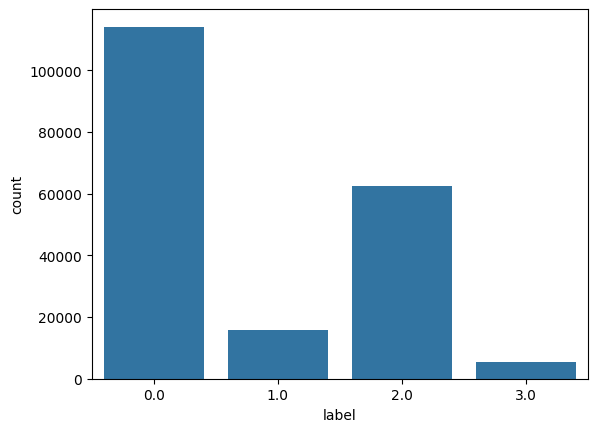

In [ ]:
sns.countplot(data = train_df, x = "label")

In [ ]:
train_df.to_csv("train_df.csv")

In [ ]:
print(train_df.shape
, final_df.shape, df_train.shape) #just to verfiy the splitting wnet smoothly

print(test_df.shape
, final_df.shape, df_test.shape)

(198000, 37) (300000, 37) (198000, 16)
(102000, 37) (300000, 37) (102000, 15)


### After splitting train and test data: Real ML 

In [ ]:
train_df.columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2',
       'race', 'religion', 'gender', 'disability', 'comment', 'label',
       'is_train', 'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'is_trans', 'comment_len',
       'word_cnt', 'avg_words', 'num_!', 'num_ques', 'emoji_counts',
       'votes_ratio', 'upvote_log1', 'downvote_log1', 'engagement_score',
       'emoticon_density', 'post_comments_count', 'if_1_log', 'if_2_log',
       'if_interaction_log', 'sentiment_vader', 'if_interaction_sentiment'],
      dtype='str')

In [ ]:
x_ = train_df.drop(columns=['label'])
y_ = train_df['label'].astype(int).values
x_.shape, y_.shape

((198000, 36), (198000,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_,
    y_,
    test_size=0.2,
    stratify=y_,
    random_state=42
)

In [ ]:
# X_train["post_mean"] = X_train["post_id"].map(post_stats["post_mean"])
# X_train["post_std"] = X_train["post_id"].map(post_stats["post_std"])
post_stats = X_train.assign(label= y_train).groupby("post_id")['label'].agg(post_mean = 'mean', post_std = "std")
# mapping the label mean found from train to val and test
post_stats.reset_index().set_index("post_id")

for data in [X_train, X_val, test_df]:
    data["post_mean"] = data["post_id"].map(post_stats["post_mean"])
    data["post_std"] = data["post_id"].map(post_stats["post_std"]).fillna(0.0)
# X_train[["post_id", 'post_mean',"post_std"]].groupby("post_id").value_counts()

## Encoding categorical features:

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True) #to avoid crash on unseen dataset

In [ ]:
categories = ['race', 'religion', 'gender']

X_train_ohe = ohe.fit_transform(X_train[categories])
X_val_ohe = ohe.transform(X_val[categories])
X_test_ohe = ohe.transform(test_df[categories])

In [ ]:
# encoded_df = pd.DataFrame(X_train_ohe.toarray(), columns= ohe.get_feature_names_out(['race', 'religion', 'gender']))
# display(encoded_df.head()) # the encoded data

### Using TF-IDF for comments


In [ ]:
train_df.shape

(198000, 37)

In [ ]:
# try#1:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(max_features=20000, 
#                         ngram_range=(1,2), 
#                         min_df=5, 
#                         stop_words='english', 
#                         lowercase=True
# )

# X_train_text = tfidf.fit_transform(X_train['comment'])
# X_val_text = tfidf.transform(X_val['comment'])
# X_test_text = tfidf.transform(test_df['comment'])

In [ ]:
#try#2
#@title Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

# word_tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),
#     min_df=3,
#     lowercase=True
# )

# char_tfidf = TfidfVectorizer(
#     max_features=5000,
#     analyzer='char',
#     ngram_range=(3,5)
# )

# X_train_word = word_tfidf.fit_transform(X_train['comment'])
# X_val_word   = word_tfidf.transform(X_val['comment'])
# X_test_word  = word_tfidf.transform(test_df['comment'])

# X_train_char = char_tfidf.fit_transform(X_train['comment'])
# X_val_char   = char_tfidf.transform(X_val['comment'])
# X_test_char  = char_tfidf.transform(test_df['comment'])

#have already saved!

In [ ]:
# #@title: trying senstece transformer instead of tf-idf to improve context
# from sentence_transformers import SentenceTransformer
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import loguniform

# import numpy as np

# model = SentenceTransformer("all-MiniLM-L6-v2")

# train_text_emb = model.encode(
#     X_train["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# val_text_emb = model.encode(
#     X_val["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# test_text_emb = model.encode(
#     test_df["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

In [ ]:
from scipy.sparse import hstack, load_npz
# X_train_tfidf = hstack([X_train_word, X_train_char]).tocsr()
# X_val_tfidf   = hstack([X_val_word, X_val_char]).tocsr()
# X_test_tfidf  = hstack([X_test_word, X_test_char]).tocsr()
#have already saved

X_train_tfidf = load_npz('X_train_tfidf.npz')
X_val_tfidf   = load_npz('X_val_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

# X_train_text = hstack([X_train_word, X_train_char])
# X_val_text   = hstack([X_val_word, X_val_char])
# X_test_text  = hstack([X_test_word, X_test_char])

#adding the embeddings 
train_text_emb = np.load('train_embeddings.npy')
val_text_emb = np.load('val_embeddings.npy')
test_text_emb = np.load('test_embeddings.npy')
# # join all the sparse matrices

from scipy.sparse import csr_matrix

X_train_emb_sparse = csr_matrix(train_text_emb)
X_val_emb_sparse   = csr_matrix(val_text_emb)
X_test_emb_sparse  = csr_matrix(test_text_emb)

In [ ]:
# from scipy.sparse import save_npz
# save_npz('X_train_tfidf',X_train_tfidf )
# save_npz('X_val_tfidf',X_val_tfidf )
# save_npz('X_test_tfidf',X_test_tfidf )
#can't waste time again and again

In [ ]:
# train_df.drop(['post_id'], axis=1, inplace=True) #will decide later
#mergin the ohe and main dataset
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3','if_1_log',
                'if_2_log','disability', 'weekend', 'created_hour','is_trans',
                'gender_missing', 'comment_len','avg_words',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader','if_interaction_sentiment', 'post_mean', 'post_std']  #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]
 #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]

In [ ]:
#scalling the numericals 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_col])
X_val_num   = scaler.transform(X_val[numerical_col])
X_test_num  = scaler.transform(test_df[numerical_col])

In [ ]:
sns.scatterplot(data = X_train, x = 'label', y = 'post_mean')

ValueError: Could not interpret value `label` for `x`. An entry with this name does not appear in `data`.

In [ ]:
#Merging everything 
# from scipy.sparse import hstack

# X_train_final = hstack([X_train_text, X_train_ohe, X_train_num])
# X_val_final   = hstack([X_val_text, X_val_ohe, X_val_num])
# X_test_final  = hstack([X_test_text, X_test_ohe, X_test_num])

In [ ]:
# x = X_train_final
# import copy 
# X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

In [ ]:
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_final.npz', X_train_final)
# save_npz('X_val_final.npz', X_val_final)
# save_npz('X_test_final.npz', X_test_final)

In [ ]:
# y_train.('y_train.csv', index  = False)
# y_val.to_csv('y_val.csv', index  = False)
# np.save('y_train', y_train)
# np.save('y_val', y_val)

### Merger for final Dataset

In [ ]:
# final dataset
X_train_final = hstack([
    X_train_tfidf,
    X_train_emb_sparse,
    X_train_ohe,
    X_train_num
])

X_val_final = hstack([
    X_val_tfidf,
    X_val_emb_sparse,
    X_val_ohe,
    X_val_num
])

X_test_final = hstack([
    X_test_tfidf,
    X_test_emb_sparse,
    X_test_ohe,
    X_test_num
])

In [ ]:
#merge#2
# X_train_final = np.hstack([train_text_emb, X_train_ohe, X_train_num])
# X_val_final   = np.hstack([val_text_emb, X_val_ohe, X_val_num])
# X_test_final   = np.hstack([test_text_emb, X_test_ohe, X_test_num])

In [ ]:
# from scipy.sparse import csr_matrix

# X_train_num = csr_matrix(train_df[numerical_col].values)
# X_test_num = csr_matrix(test_df[numerical_col].values)

In [ ]:
# #merge all
# from scipy.sparse import hstack

# X_train = hstack([X_train_num, X_train_ohe, X_train_text], format='csr')
# X_test = hstack([X_test_num, X_test_ohe, X_test_text], format='csr')


In [ ]:
# Am saving the manipulated dataset here so we can perform modelling in another notebook
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_.npz', X_train)
# save_npz('X_test_.npz', X_test)

In [ ]:
# print(X_train.shape)
# print(X_test.shape)

In [ ]:
# train_df['label']

## visualisations and insigsts

In [ ]:
# will go the visaulising in another notebook
# final_df.to_csv('final_df.csv', index  = False)
# train_df.to_csv('train_df.csv', index  = False)

In [ ]:
# df.to_csv('df.csv', index  = False)

In [ ]:
import copy
X_train_split = copy.deepcopy(X_train_final)
X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

### **Updation after analysising with visualisations:**


Alright after seeing the accuracy results 

### **Model training and testing**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight={
        0: 1,
        1: 1.2,
        2: 1,
        3: 3 
    },
    C=2.0,
    n_jobs=-1
)

lr = LogisticRegression()

In [ ]:
lr.fit(X_train_split, y_train_split)
y_pred = lr.predict(X_val_split)


In [ ]:
print(classification_report(y_val_split, y_pred))
print("f1_sctrore: ", f1_score(y_val_split, y_pred, average='macro'))

#output:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     22835
           1       0.75      0.75      0.75      3183
           2       0.87      0.88      0.87     12488
           3       0.61      0.68      0.64      1094

    accuracy                           0.90     39600
   macro avg       0.79      0.81      0.80     39600
weighted avg       0.90      0.90      0.90     39600

Macro F1: 0.8026683849892419